### Remap IMBIE basins to tx2_3

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import xesmf, intake
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import warnings
warnings.filterwarnings("ignore")

In [3]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260305


In [4]:
def plot_masks(data, lon, lat, ax, title=''):
  '''Used to generate the maps'''
  extent = [-180, 180, -90, -50]
  lonRange=(-360, 360.); latRange=(extent[2], extent[3])
  ax.set_extent(extent, ccrs.PlateCarree())
  #ax.add_feature(cartopy.feature.LAND)
  cs = ax.pcolormesh(lon,lat,data,transform=ccrs.PlateCarree())
  #cb = plt.colorbar(cs, ax=ax, orientation='horizontal', pad=0.02)
  #ax.pcolormesh(lon,lat,data)
  ax.add_feature(cartopy.feature.COASTLINE)
  circle_value = get_circle()
  ax.set_boundary(circle_value, transform=ax.transAxes)
  ax.set_title(title)
  ax.gridlines()
  ax.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
  ax.xformatter = LONGITUDE_FORMATTER
  ax.yformatter = LATITUDE_FORMATTER

In [5]:
def get_circle():
  """
  Compute a circle in axes coordinates, which we can use as a boundary
  for the map. We can pan/zoom as much as we like - the boundary will be
  permanently circular.
  """
    
  theta = np.linspace(0, 2*np.pi, 100)
  center, radius = [0.5, 0.5], 0.5
  verts = np.vstack([np.sin(theta), np.cos(theta)]).T
                     
  return mpath.Path(verts * radius + center)

In [6]:
fname = '../mesh/tx2_3v3_grid.nc'
ds_out = xr.open_dataset(fname).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b', 'nx' : 'xh', 'ny' : 'yh',
                                        'depth' : 'z_l'})
ds_out

<xarray.Dataset> Size: 42MB
Dimensions:  (yh: 480, xh: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: yh, xh, nxp, nyp
Data variables: (12/20)
    lon      (yh, xh) float64 2MB ...
    lat      (yh, xh) float64 2MB ...
    ulon     (yh, nxp) float64 2MB ...
    ulat     (yh, nxp) float64 2MB ...
    vlon     (nyp, xh) float64 2MB ...
    vlat     (nyp, xh) float64 2MB ...
    ...       ...
    tarea    (yh, xh) float64 2MB ...
    tmask    (yh, xh) float64 2MB ...
    angle    (yh, xh) float64 2MB ...
    z_l      (yh, xh) float64 2MB ...
    ar       (yh, xh) float64 2MB ...
    egs      (yh, xh) float64 2MB ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2026-03-05T14:49:28.971877
    type:         Glogal 2/3 degree grid file

In [7]:
infile = '/glade/work/gmarques/Projects/POP_CISM/imbie_basin_with_grids.nc'
ds_in = xr.open_dataset(infile).rename({'Lon': 'lon','Lat': 'lat'})
ds_in

<xarray.Dataset> Size: 12MB
Dimensions:   (ny: 761, nx: 761)
Dimensions without coordinates: ny, nx
Data variables:
    basin_id  (ny, nx) float32 2MB ...
    x1        (nx) float32 3kB ...
    y1        (ny) float32 3kB ...
    X         (ny, nx) float32 2MB ...
    Y         (ny, nx) float32 2MB ...
    lat       (ny, nx) float32 2MB ...
    lon       (ny, nx) float32 2MB ...
Attributes:
    history:  Mon May 18 21:46:57 2020: ncap2 -s where(basin_id==0) basin_id=...
    NCO:      netCDF Operators version 4.8.1 (Homepage = http://nco.sf.net, C...

In [8]:
ds_in = ds_in.assign_coords(lon=ds_in.lon - 180)

In [9]:
ds_in = ds_in.assign_coords(lat=ds_in.lat)

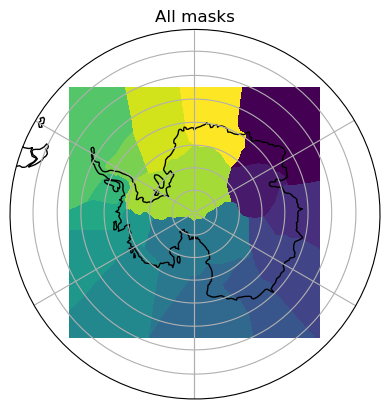

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_masks(ds_in.basin_id.values, ds_in.lon.values, ds_in.lat.values, ax, 'All masks')

In [11]:
print('The first mask # is {}, and the last is {}'.format( \
        ds_in.basin_id.min().values,ds_in.basin_id.max().values))
# total number of masks
total_masks = int((ds_in.basin_id.max().values - ds_in.basin_id.min().values) + 1)
print('Total # of masks is {}'.format(total_masks))

The first mask # is 1.0, and the last is 16.0
Total # of masks is 16


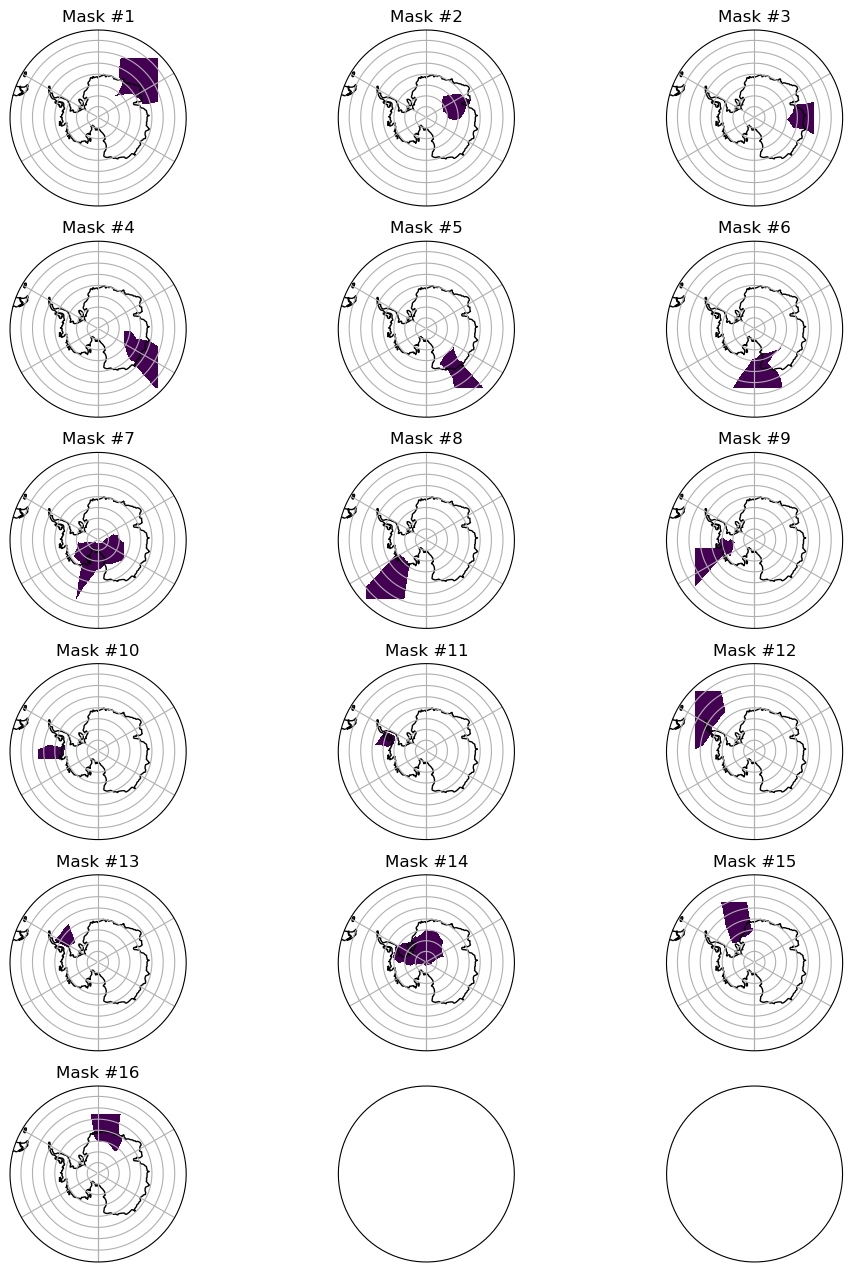

In [12]:
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(12,16),
                       subplot_kw={'projection': ccrs.SouthPolarStereo()})
axis=ax.flatten()
for i in np.arange(total_masks):   
 plot_masks(ds_in['basin_id'].where(ds_in.basin_id==i+1).values, 
            ds_in.lon.values, ds_in.lat.values, axis[i], title='Mask #'+str(i+1))

In [13]:
def regrid_tracer(ds_in, ds_out, method='nearest_d2s'):

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=True,
    )
    fld_out = regrid(ds_in)
    return fld_out

In [14]:
# create DataArray for output
ny, nx = ds_out.lat.shape
basin_id_tx2_3 = xr.DataArray(np.zeros((total_masks,ny,nx)),dims=['region','yh','xh']).rename('basin_masks')
basin_id_tx2_3

<xarray.DataArray 'basin_masks' (region: 16, yh: 480, xh: 540)> Size: 33MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(16, 480, 540))
Dimensions without coordinates: region, yh, xh

In [15]:
ds_in

<xarray.Dataset> Size: 12MB
Dimensions:   (ny: 761, nx: 761)
Coordinates:
    lat       (ny, nx) float32 2MB -51.85 -51.9 -51.94 ... -51.94 -51.9 -51.85
    lon       (ny, nx) float32 2MB -135.0 -135.1 -135.2 ... 44.85 44.92 45.0
Dimensions without coordinates: ny, nx
Data variables:
    basin_id  (ny, nx) float32 2MB 8.0 8.0 8.0 8.0 8.0 ... 1.0 1.0 1.0 1.0 1.0
    x1        (nx) float32 3kB ...
    y1        (ny) float32 3kB ...
    X         (ny, nx) float32 2MB ...
    Y         (ny, nx) float32 2MB ...
Attributes:
    history:  Mon May 18 21:46:57 2020: ncap2 -s where(basin_id==0) basin_id=...
    NCO:      netCDF Operators version 4.8.1 (Homepage = http://nco.sf.net, C...

In [16]:
for i in np.arange(total_masks):
  print('Processing  ',i+1)
  dummy = ds_in['basin_id'].where(ds_in['basin_id']==i+1).fillna(0)
  dummy1 = regrid_tracer(dummy, ds_out)
  dummy2 = xr.where(dummy1 != 0, 1, 0)
  basin_id_tx2_3[i,:] = dummy2.data #np.nan_to_num(dummy1.data)

Processing   1
Processing   2
Processing   3
Processing   4
Processing   5
Processing   6
Processing   7
Processing   8
Processing   9
Processing   10
Processing   11
Processing   12
Processing   13
Processing   14
Processing   15
Processing   16


In [17]:
basin_id_tx2_3 = basin_id_tx2_3.assign_coords(lon=ds_out.lon)
basin_id_tx2_3 = basin_id_tx2_3.assign_coords(lat=ds_out.lat)

### Select just the southern ocean from ds_out

In [18]:
ds_out_so = basin_id_tx2_3.sel(yh=slice(0,180))

In [19]:
ds_out_so

<xarray.DataArray 'basin_masks' (region: 16, yh: 180, xh: 540)> Size: 12MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [1., 1., 0., ..., 1., 1., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(16, 180, 540))
Coordinates:
    lon      (yh, xh) float64 778kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
    lat      (yh, xh) float64 778kB -81.56 -81.56 -81.56 ... -28.72 -28.72
Dimensions without coordinates: region, yh, xh

##### Visual inspection
Make sure original and remapped plots look similar.

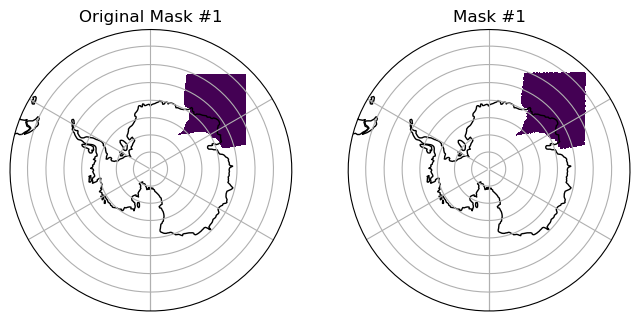

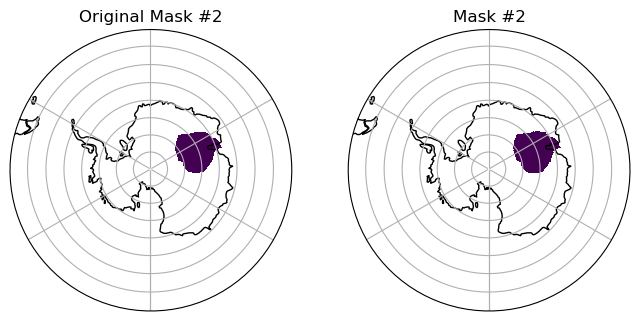

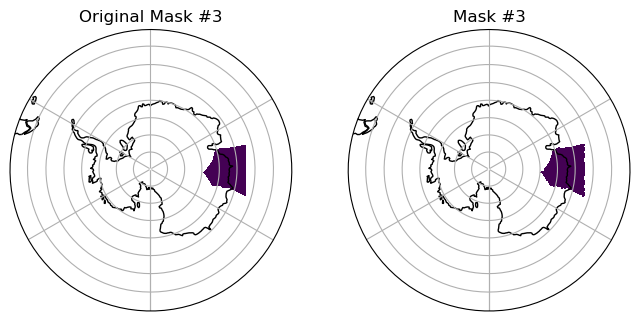

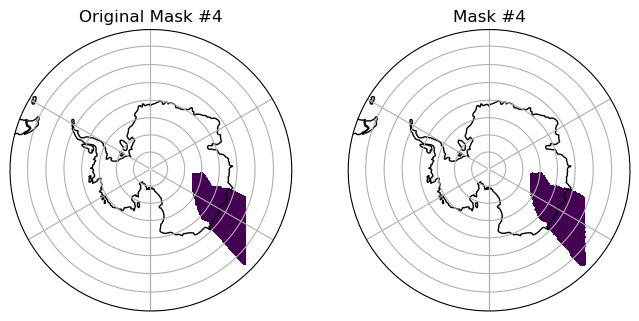

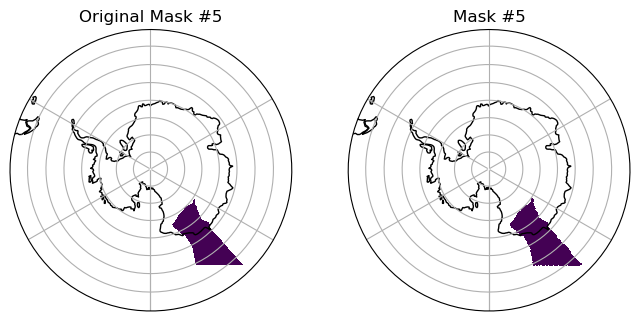

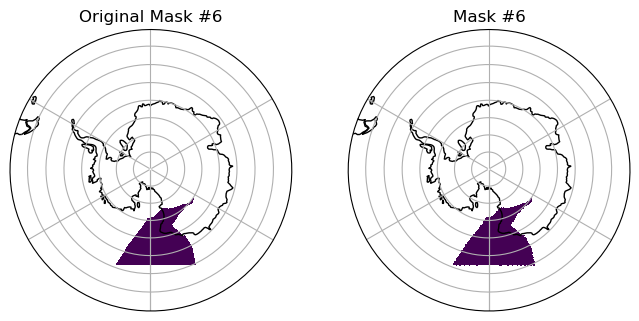

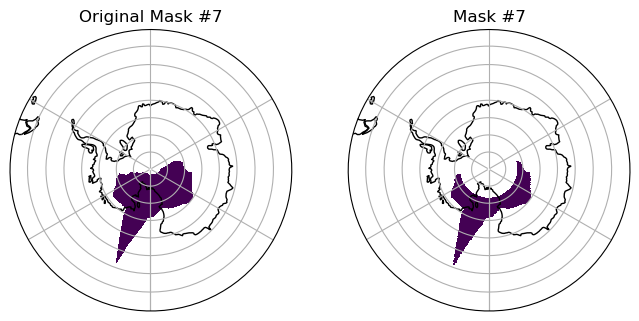

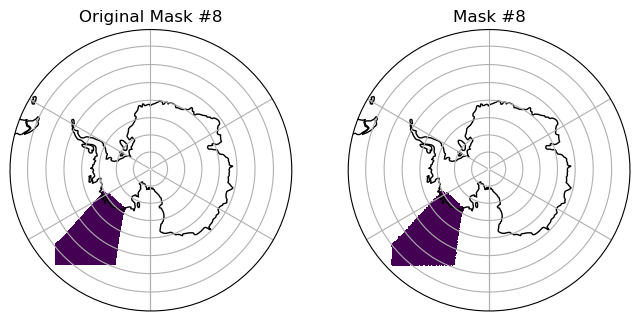

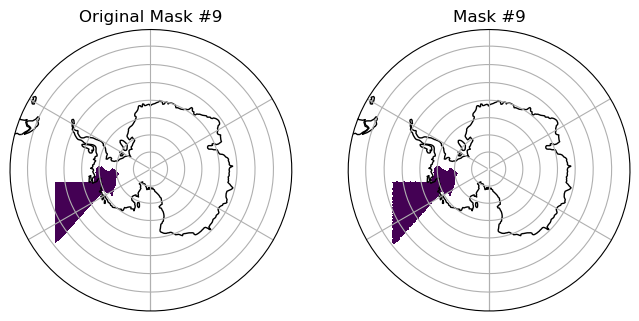

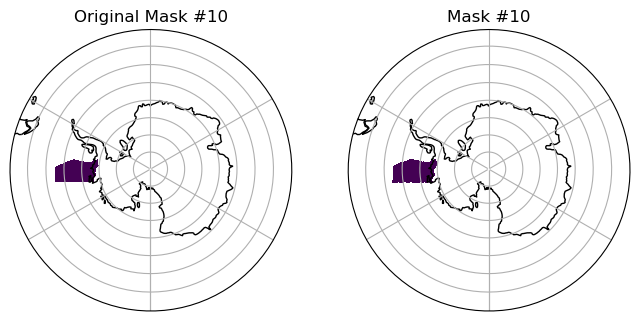

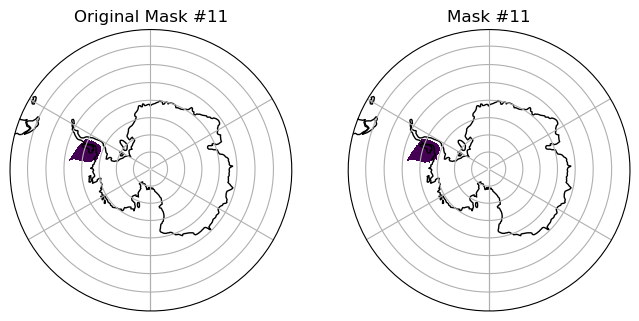

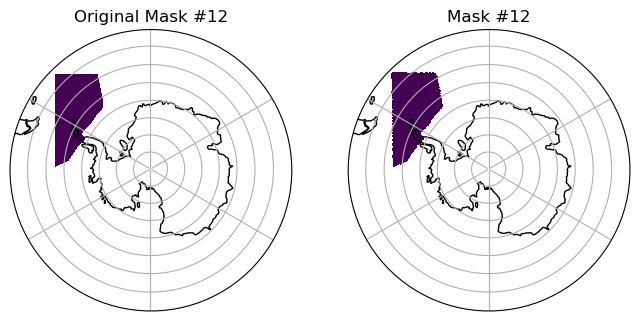

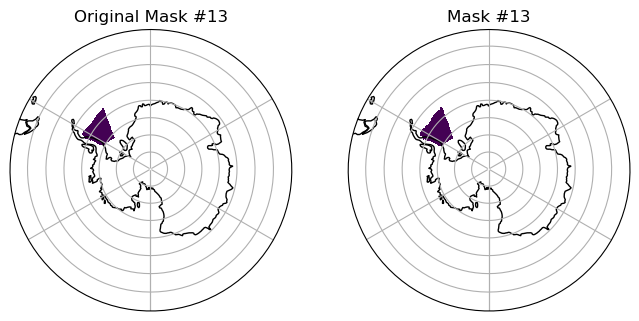

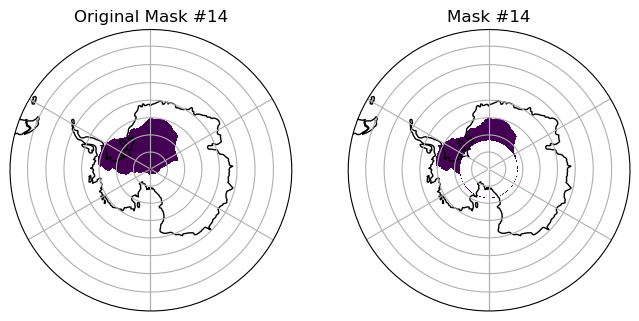

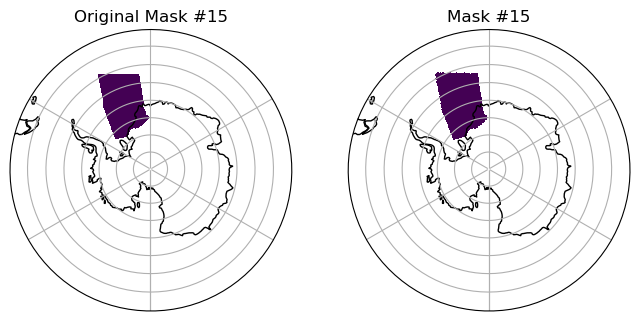

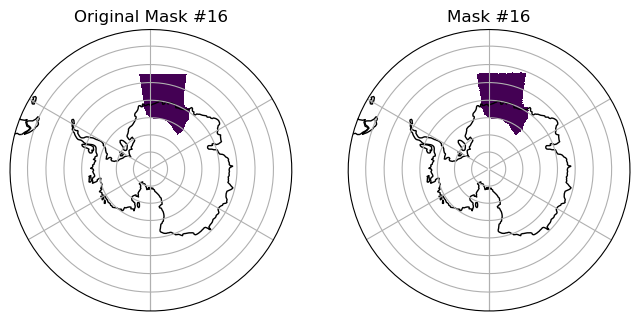

In [20]:
%matplotlib inline

for i in np.arange(total_masks):
  fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4),
                       subplot_kw={'projection': ccrs.SouthPolarStereo()})
  axis=ax.flatten()
  # original
  plot_masks(ds_in['basin_id'].where(ds_in.basin_id==i+1).values, 
            ds_in.lon.values, ds_in.lat.values, axis[0], title='Original Mask #'+str(i+1))
  # remmaped
  dummy1 = np.ma.masked_invalid(ds_out_so[i,:].values)
  dummy2 = np.ma.masked_where(ds_out_so[i,:].values==0, dummy1)
  plot_masks(dummy2,ds_out_so.lon.values, ds_out_so.lat.values, 
             ax[1], title='Mask #'+str(i+1))


In [21]:
basin_id_tx2_3

<xarray.DataArray 'basin_masks' (region: 16, yh: 480, xh: 540)> Size: 33MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [1., 1., 0., ..., 1., 1., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(16, 480, 540))
Coordinates:
    lon      (yh, xh) float64 2MB -286.7 -286.0 -285.3 ... 72.97 72.98 73.0
    lat      (yh, xh) float64 2MB -81.56 -81.56 -81.56 ... 50.27 50.11 49.99
Dimensions without coordinates: region, yh, xh

In [22]:
basin_id_tx2_3.attrs['description'] = 'Imbie basins remapped to tx2_3'
basin_id_tx2_3.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
basin_id_tx2_3.attrs['date'] = today
basin_id_tx2_3.attrs['url'] = 'https://github.com/NCAR/tx2_3/basin_masks'
# save
fname = 'imbie_basins_tx2_3_{}.nc'.format(today)

basin_id_tx2_3.to_netcdf(fname)